# Examples

Author: Bruno Marcos

Date: February 19, 2026

## Settings

In [20]:
# Load functions
source("../R/ndc_url.R")
source("../R/ndc_get.R")
source("../R/gm_url.R")
source("../R/gm_get.R")

# Load packages
library(httr)
library(jsonlite)
library(geojsonio)
library(terra)

# Define parameters
mytoken <- Sys.getenv("AGRODATACUBE_TOKEN") # (replace by your own token)
mytoken2 <- Sys.getenv("NDC_TOKEN") # (replace by your own token)
mypolygon1 <- "POLYGON((4.2 52, 4.2 53, 4.3 53, 4.3 52, 4.2 52))"
mypolygon2 <- "POLYGON((219478 481588.256000001,219478 497638.432,237339.072000001 497638.432,237339.072000001 481588.256000001,219478 481588.256000001))"
mypolygon3 <- "POLYGON((175742 445233,175742 446118,177050 446118,177050 445233,175742 445233))"
myparams <- c(date = "20251225",
              xmin = 684613,
              xmax = 685907,
              ymin = 5763913,
              ymax = 5764822,
              format = "tiff")

# 1. Using the *AgroDataCube* REST API

**Note:** All examples are currently based on the *AgroDataCube* [Postman documentation for V2.1](https://documenter.getpostman.com/view/3284162/TVeqd7aa).

## 1.1 Fields

Requests to retrieve data from the crop registration datasets, see [RVO](https://www.rvo.nl/) website. Several years of crop registrations are available in the Cube. Crop fields change per year, and are recorded by farmers with an indication of the crop that will be grown on the field. The geometries of the fields are provided as-is, and might contain geometric anomalies.

Once the ID of a specific field is known, it can be used to request addition and detailed information for that particular field:

In [4]:
myurl <- ndc_url(option = "Fields",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            year = 2016,
                            cropname = "mais",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&year=2016&cropname=mais&output_epsg=4326

In [5]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
print(myres_sf)

Simple feature collection with 5 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 4.2 ymin: 52 xmax: 4.2925 ymax: 52.0048
Geodetic CRS:  WGS 84
       area grondgebruik crop_code year   crop_name perimeter fieldid                       geometry
1 18907.379     Bouwland       259 2016 Mais, snij-   589.857 5871107 POLYGON ((4.2905 52.0001, 4...
2 17417.011     Bouwland       259 2016 Mais, snij-   564.305 6121295 POLYGON ((4.2867 52, 4.2849...
3  7040.033     Bouwland       259 2016 Mais, snij-   362.238 5552695 POLYGON ((4.2779 52, 4.2762...
4   594.969     Bouwland       259 2016 Mais, snij-   120.783 5748120 POLYGON ((4.2759 52.0002, 4...
5    10.986     Bouwland       259 2016 Mais, snij-    15.796 6155689 POLYGON ((4.2001 52.0048, 4...


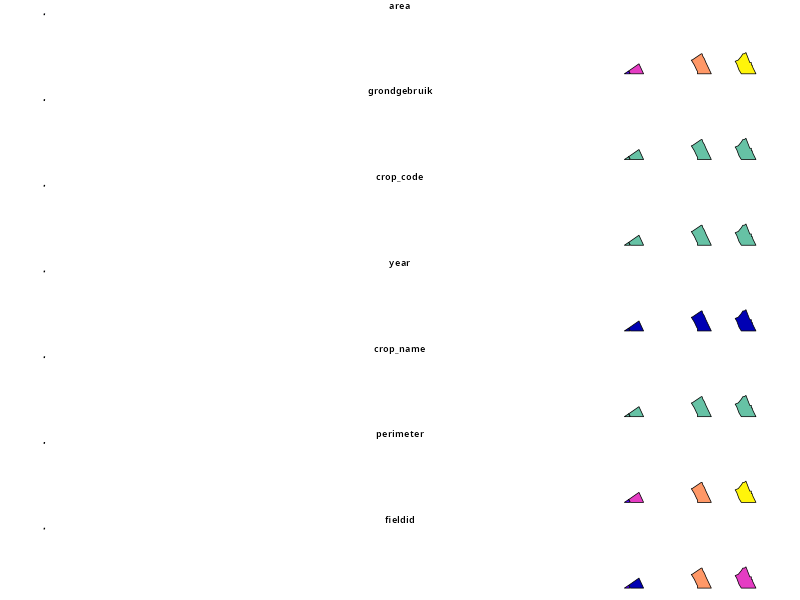

In [6]:
plot(myres_sf)

### 1.1.1 Retrieve the geometry and crop information of the intersections of the supplied geometry and the fields

In [7]:
myurl <- ndc_url(option = "Fields",
                 params = c(geometry = mypolygon2,
                            fieldid = "9403114",
                            epsg = "28992",
                            output_epsg = "4326",
                            year = 2016,
                            cropcode = "265",
                            cropname = "mais",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&fieldid=9403114&epsg=28992&output_epsg=4326&year=2016&cropcode=265&cropname=mais&page_size=25&page_offset=0

In [25]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
knitr::kable(myres_df$metadata)



|column_name  |description                                                                            |units |
|:------------|:--------------------------------------------------------------------------------------|:-----|
|area         |Area of a geometry                                                                     |m2    |
|crop_code    |Code for the crop as supplied by RVO                                                   |NULL  |
|crop_name    |Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years. |NULL  |
|fieldid      |Unique id of a parcel in the AgroDataCube unique per parcel per year                   |NULL  |
|geom         |The geometry of an object or intersection depending on the resource and the parameters |NULL  |
|grondgebruik |Categorized landuse at the parcel                                                      |NULL  |
|perimeter    |Perimeter of geometry                                                                  |m     |

### 1.1.2 Retrieve the geometry and crop information for a specific crop field

In [26]:
myurl <- ndc_url(option = "Fields",
                 params = c(geometry = mypolygon2,
                            fieldid = "9403114",
                            output_epsg = "4326",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&fieldid=9403114&output_epsg=4326&page_offset=0

In [28]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
knitr::kable(myres_df$metadata)



|column_name  |description                                                                            |units |
|:------------|:--------------------------------------------------------------------------------------|:-----|
|area         |Area of a geometry                                                                     |m2    |
|crop_code    |Code for the crop as supplied by RVO                                                   |NULL  |
|crop_name    |Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years. |NULL  |
|fieldid      |Unique id of a parcel in the AgroDataCube unique per parcel per year                   |NULL  |
|geom         |The geometry of an object or intersection depending on the resource and the parameters |NULL  |
|grondgebruik |Categorized landuse at the parcel                                                      |NULL  |
|perimeter    |Perimeter of geometry                                                                  |m     |

## 1.2 Altitude (AHN)

This contains requests to retrieve AHN (‘Actueel Hoogtebestand Nederland’) data. AHN is provided as Open Data by Rijkswaterstaat.

As of december 2022 AHN2 has been replaced by AHN3.

For more details please see: [Rijkswaterstaat website AHN](https://www.rijkswaterstaat.nl/zakelijk/open-data/actueel-hoogtebestand-nederland/)

### 1.2.1 Altitude zonal statistics for supplied geometry

In [34]:
myurl <- ndc_url(option = "AHN",
                 params = c(geometry = mypolygon1,
                            epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ahn?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326

In [41]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
print(unlist(myres_df$features$properties))

       area         min         max        mean 
755607361.1      -534.9      3364.6       166.6 


### 1.2.2 Raster data geotiff for AHN (ahn_image)

In [42]:
myurl <- ndc_url(option = "AHN_image",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ahn_image?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&output_epsg=4326

In [43]:
myres <- ndc_get(url = myurl, token = mytoken)
print(prettify(toJSON(myres, auto_unbox = TRUE)))

{
    "status": "Geometry area (m2) 950792200 exceeds limit of 100000000"
}
 


## 1.3 Meteo

Requests to retrieve information about ánd from the KNMI (the Royal Netherlands Meteorological Institute) weather stations for which data has been stored in the Cube. This data is provided as Open Data by KNMI, see: <https://data.knmi.nl/>.

Once the ID of a meteostation has been retrieved it can be used to request further details and the weather observations of that particular station.

### 1.3.1 Return a list of all meteostations for which data is available

In [44]:
myurl <- ndc_url(option = "Meteo_stations",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteostations?output_epsg=4326&page_size=25&page_offset=0

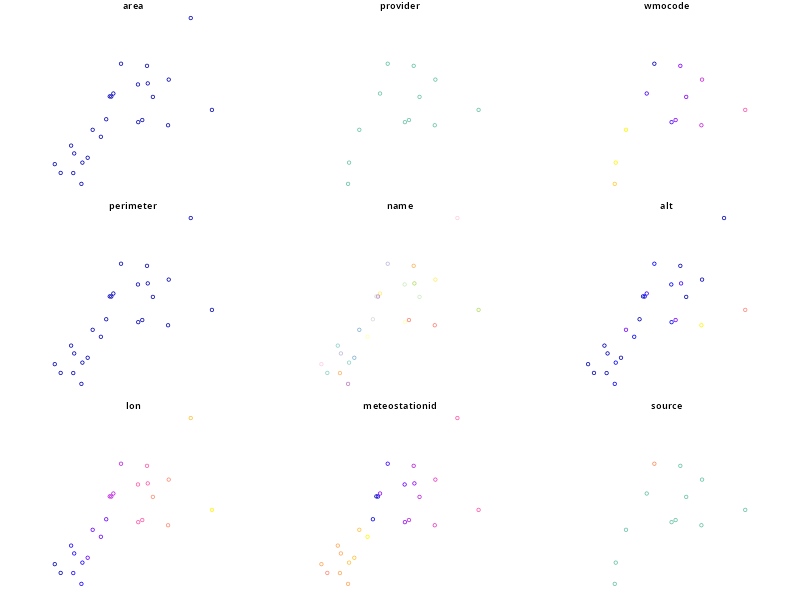

Warning message:
plotting the first 9 out of 10 attributes; use max.plot = 10 to plot all 


In [45]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

### 1.3.2 Return the data for the given meteostation

In [46]:
myurl <- ndc_url(option = "Meteo_stations",
                 params = c(output_epsg = "4326",
                            meteostation = "330",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteostations/330?output_epsg=4326&page_size=25&page_offset=0

In [47]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
print(myres_sf)

Simple feature collection with 1 feature and 10 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 4.122 ymin: 51.992 xmax: 4.122 ymax: 51.992
Geodetic CRS:  WGS 84
  area   provider wmocode perimeter             name   alt   lon meteostationid
1    0 KNMI_DAILY   63300         0 Hoek van Holland 11.86 4.122            330
                                                                                                        source
1 KONINKLIJK NEDERLANDS METEOROLOGISCH INSTITUUT (KNMI) (http://www.knmi.nl/klimatologie/metadata/debilt.html)
     lat             geometry
1 51.992 POINT (4.122 51.992)


### 1.3.3 Retrieve weather data from one of the meteostations and for a specific date

In [48]:
myurl <- ndc_url(option = "Meteo_data",
                 params = c(output_epsg = "4326",
                            stationid = "210",
                            date = "20160101",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteodata?output_epsg=4326&stationid=210&date=20160101&page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  1 rows x 2 columns

In [169]:
knitr::kable(data.frame(myres_df$features$properties))



|area       |perimeter |id |name          |
|:----------|:---------|:--|:-------------|
|5748751544 |382644.1  |5  |Fryslân       |
|5136514976 |561381.7  |3  |Gelderland    |
|5081754945 |518496.7  |9  |Noord-Brabant |
|4091738584 |394724.8  |10 |Noord-Holland |
|3420863133 |425722    |8  |Overijssel    |
|3418526942 |347276.4  |1  |Zuid-Holland  |
|2960049439 |310841.4  |11 |Groningen     |
|2933893552 |264157.4  |7  |Zeeland       |
|2680337505 |283716.5  |12 |Drenthe       |
|2412296369 |243053.3  |4  |Flevoland     |
|2209221445 |463760.4  |6  |Limburg       |
|1449119349 |283736.5  |2  |Utrecht       |

### 1.3.4 Retrieve weather data from one of the meteostations for a specified time period

In [133]:
myurl <- ndc_url(option = "Meteo_data",
                 params = c(output_epsg = "4326",
                            meteostation = "330",
                            fromdate = "20160101",
                            todate = "20251231",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteodata?output_epsg=4326&meteostation=330&fromdate=20160101&todate=20251231&page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  25 rows x 20 columns

In [68]:
print(knitr::kable(head(as.data.frame(myres_df$features$properties))))



|meteostationid |datum      |mean_temperature |min_temperature |max_temperature |sunshine_duration |global_radiation |precipitation |mean_sea_level_pressure |mean_humidity |max_humidity |potential_evapotranspiration |vector_mean_windspeed |daily_mean_windspeed |max_hourly_mean_windspeed |hourly_division_max_windspeed |min_hourly_mean_windspeed |hourly_division_min_windspeed |max_gust_windspeed |hourly_division_max_gust_windspeed |
|:--------------|:----------|:----------------|:---------------|:---------------|:-----------------|:----------------|:-------------|:-----------------------|:-------------|:------------|:----------------------------|:---------------------|:--------------------|:-------------------------|:-----------------------------|:-------------------------|:-----------------------------|:------------------|:----------------------------------|
|330            |2016-01-01 |6.6              |2.8             |9               |3.5               |282              |0         

## 1.4 Soil

Requests to retrieve data about soil conditions from the BOFEK 2012 datasets ánd the Dutch soil map 1:50.000 (2014).

“BOFEK 2012”: This is a rather complex but interesting dataset derived from the soil map of the Netherlands. It contains a classification in 72 categories of soil characteristics, and is for example used as input for simulation models.

The dataset is created and provided by WUR. For more information please see <https://www.wur.nl/nl/show/Bodemfysische-Eenhedenkaart-BOFEK2012.htm>.

A soilparamid (soil parameter ID) is needed to request the data. It can be retrieved for a particular field, once the ID of the field is known. Please see the Fields requests.

“Dutch soil map 1:50.000”: This dataset is provided by WUR, and also avaible as Open Data. For more information please see <https://www.wur.nl/nl/show/Bodemkaart-1-50-000.htm>.

### 1.4.1 Return all the information for the given `soilparamid`

In [69]:
myurl <- ndc_url(option = "Soilparams",
                 params = c(soilparamid = "101",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soilparams?soilparamid=101&page_size=25&page_offset=0

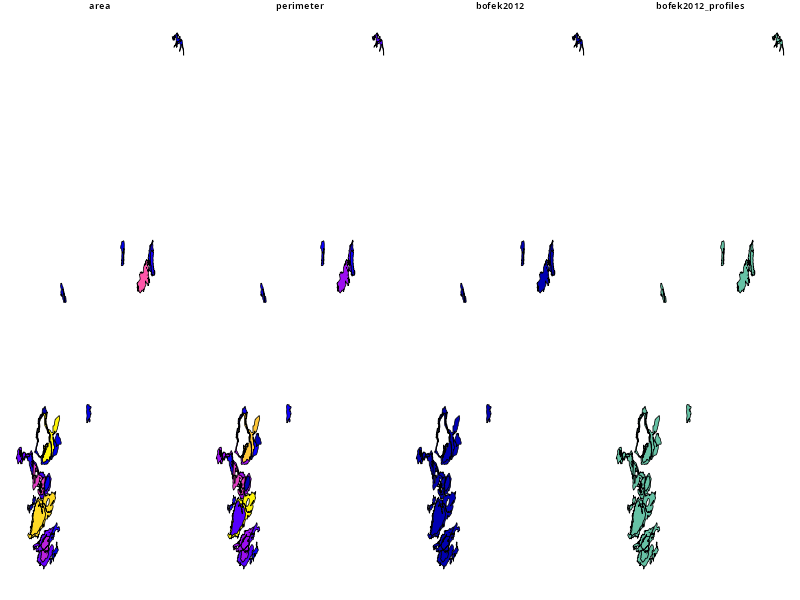

In [71]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
suppressWarnings(plot(myres_sf))

### 1.4.2 Return the intersections of the supplied `geometry` and soilmap

In [72]:
myurl <- ndc_url(option = "Soiltypes",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soiltypes?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&output_epsg=4326&page_size=25&page_offset=0

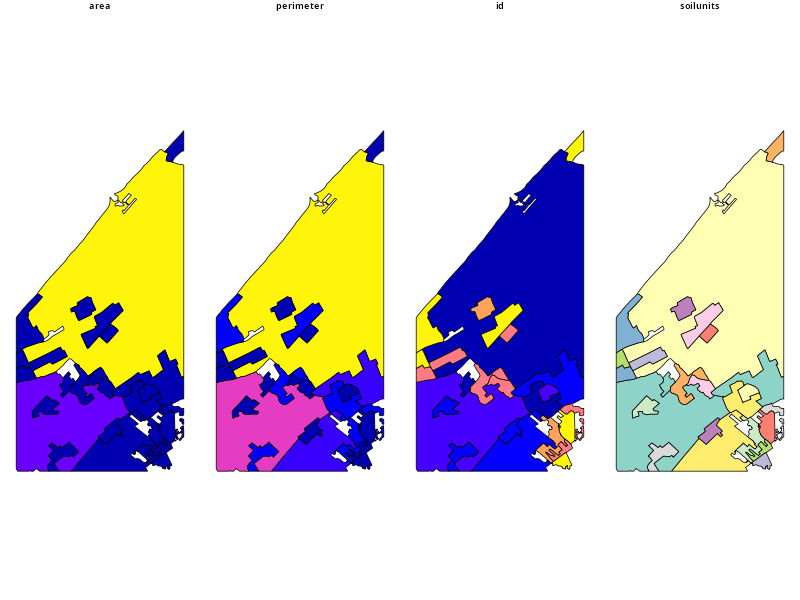

In [73]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

### 1.4.3 Return all the information for the given soilmap `entityid`

In [74]:
myurl <- ndc_url(option = "Soiltypes",
                 params = c(entityid = "49100",
                            output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soiltypes?entityid=49100&output_epsg=4326&page_size=25&page_offset=0

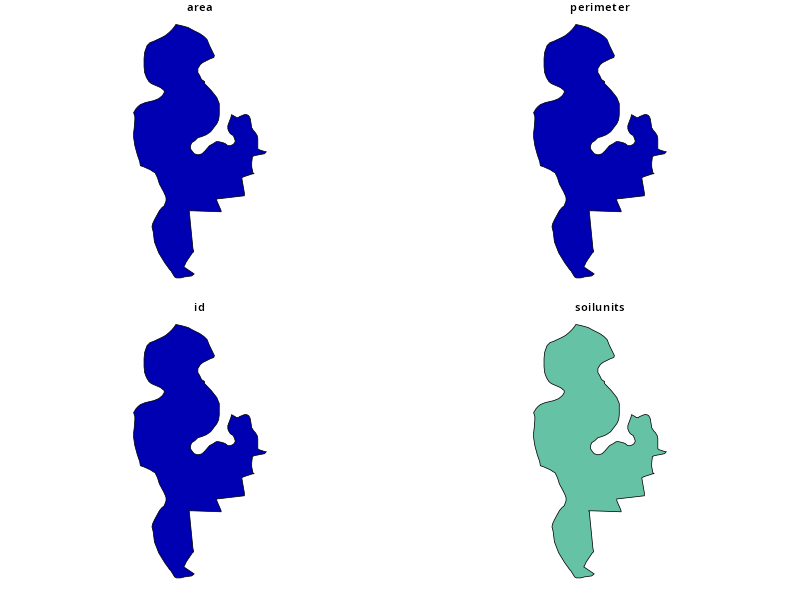

In [75]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

## 1.5 Vegetation (NDVI)

NDVI (Normalized Difference Vegetation Index)

### 1.5.1 NDVI statistics

In [136]:
myurl <- ndc_url(option = "NDVI",
                 params = c(geometry = mypolygon2,
                            date = "20191110",
                            epsg = "28992",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ndvi?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&date=20191110&epsg=28992&output_epsg=4326

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  50 rows x 5 columns

In [79]:
knitr::kable(head(myres_df$features$properties))



|datum      |ndvi_stddev |ndvi_avg |fieldid |daynr |
|:----------|:-----------|:--------|:-------|:-----|
|2019-11-10 |0.116       |0.584    |8586606 |314   |
|2019-11-10 |0.0575      |0.4804   |8586630 |314   |
|2019-11-10 |0           |0.532    |8586877 |314   |
|2019-11-10 |0.004       |0.832    |8587020 |314   |
|2019-11-10 |0           |0.664    |8587122 |314   |
|2019-11-10 |0.021       |0.8344   |8587413 |314   |

### 1.5.2 Raster data geotiff for NDVI (ndvi_image)

In [80]:
myurl <- ndc_url(option = "NDVI_image",
                 params = c(geometry = mypolygon2,
                            date = "20191110",
                            epsg = "28992",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ndvi_image?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&date=20191110&epsg=28992&output_epsg=4326

In [81]:
myres <- ndc_get(url = myurl, token = mytoken)
print(prettify(toJSON(myres, auto_unbox = TRUE)))

{
    "status": "Geometry area (m2) 286673349 exceeds limit of 100000000"
}
 


## 1.6 Codes

Requests to retrieve more details about a specific crop or soil code returned by other requests. These are the code lists as used in the original datasets, e.g. in the crop registration and the soil map.

### 1.6.1 Retrieve a list of all possible cropcodes

In [138]:
myurl <- ndc_url(option = "Cropcodes",
                 params = c(page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/cropcodes?page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  25 rows x 7 columns

In [85]:
knitr::kable(head(myres_df$features$properties))



|cropcode |cropname                                         |grondgebruik |cropid |conflict |standard_revenue |comment |
|:--------|:------------------------------------------------|:------------|:------|:--------|:----------------|:-------|
|7137     |Bonen, overig                                    |Bouwland     |570    |FALSE    |NULL             |NULL    |
|7138     |Palmkool                                         |Bouwland     |571    |FALSE    |NULL             |NULL    |
|7127     |Rietland                                         |Overige      |563    |FALSE    |NULL             |NULL    |
|7128     |Rietkraag/rietzoom                               |Overige      |564    |FALSE    |NULL             |NULL    |
|7134     |Riet in water, anders dan een subsidiabele sloot |Overige      |568    |FALSE    |NULL             |NULL    |
|7135     |Riet in een subsidiabele sloot                   |Overige      |569    |FALSE    |NULL             |NULL    |

### 1.6.2 Retrieve details for a specific cropcode

In [142]:
myurl <- ndc_url(option = "Cropcodes",
                 params = c(cropcode = "265",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/cropcodes?cropcode=265&page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  5 rows x 6 columns

In [89]:
knitr::kable(head(myres_df$features$properties))



|cropcode |cropname                                      |grondgebruik |cropid |conflict |standard_revenue |
|:--------|:---------------------------------------------|:------------|:------|:--------|:----------------|
|265      |Grasland, blijvend                            |Grasland     |209    |FALSE    |1250             |
|2652     |Granen, overig                                |Bouwland     |299    |FALSE    |1670             |
|2653     |Graszaad (inclusief klaverzaad)               |Bouwland     |300    |FALSE    |NULL             |
|2650     |Erwten inclusief schokkers (droog te oogsten) |Bouwland     |8      |FALSE    |NULL             |
|2651     |Bieten, voeder (inclusief aardperen)          |Bouwland     |298    |FALSE    |NULL             |

### 1.6.3 Retrieve a list of all possible soilcodes

In [144]:
myurl <- ndc_url(option = "Soilcodes",
                 params = c(page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/soilcodes?page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  25 rows x 3 columns

In [93]:
knitr::kable(head(myres_df$features$properties))



|soilcode      |soilname     |soiltype             |
|:-------------|:------------|:--------------------|
|Rd10C         |Lichte zavel |Rivierkleigronden    |
|Mn45Av/Mn85Cv |Zware klei   |Zeekleigronden       |
|AHa&#124;E    |Zware zavel  |Associaties          |
|Mn15A/Mn25A   |Lichte zavel |Zeekleigronden       |
|AHt           |Zand         |Associaties          |
|cZd21g        |Zand         |Kalkloze zandgronden |

### 1.6.4 Retrieve details for a specific soilcode

In [146]:
myurl <- ndc_url(option = "Soilcodes",
                 params = c(soilcode = "Hn21",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/soilcodes?soilcode=Hn21&page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  25 rows x 3 columns

In [96]:
knitr::kable(head(myres_df$features$properties))



|soilcode      |soilname       |soiltype        |
|:-------------|:--------------|:---------------|
|Hn21/Zd21     |Zand           |Podzolgronden   |
|Hn21/pZg21    |Zand           |Podzolgronden   |
|Hn21/Hn30     |Zand           |Podzolgronden   |
|kHn21/eMn82Ap |Lichte zavel   |Podzolgronden   |
|iWpc/Hn21     |Moerig op zand |Moerige gronden |
|vWpx/Hn21x    |Moerig op zand |Moerige gronden |

### 1.6.5 Retrieve detailed crop category information

In [148]:
myurl <- ndc_url(option = "Cropcategory",
                 params = c(name = "CAP",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/category?name=CAP&page_size=25&page_offset=0

In [ ]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions:  1 rows x 6 columns

In [106]:
knitr::kable(myres_df$features$properties)



|category_id |name |version |beginlifespanversion     |description                                            |category_codes                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

## 1.7 Regions

Requests for retrieving administrative boundaries of provinces, municipalities, and postal code areas, based on 2015 data. These can e.g. be used to calculate aggregated data, or as selection geometries to filter data in other requests.

### 1.7.1 Return all region boundaries based on municipalities

In [150]:
myurl <- ndc_url(option = "Municipalities",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/municipalities?output_epsg=4326&page_size=25&page_offset=0

In [151]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 4 columns

In [109]:
knitr::kable(head(myres_df$features$properties))



|area      |perimeter |id  |name             |
|:---------|:---------|:---|:----------------|
|838724702 |171387.4  |308 |Súdwest-Fryslân  |
|765388626 |119020.7  |158 |Lelystad         |
|673999999 |104868.6  |362 |Terschelling     |
|662069367 |124086    |175 |Hollands Kroon   |
|595410905 |125190.3  |133 |Noordoostpolder  |
|549109040 |143153.6  |319 |De Fryske Marren |

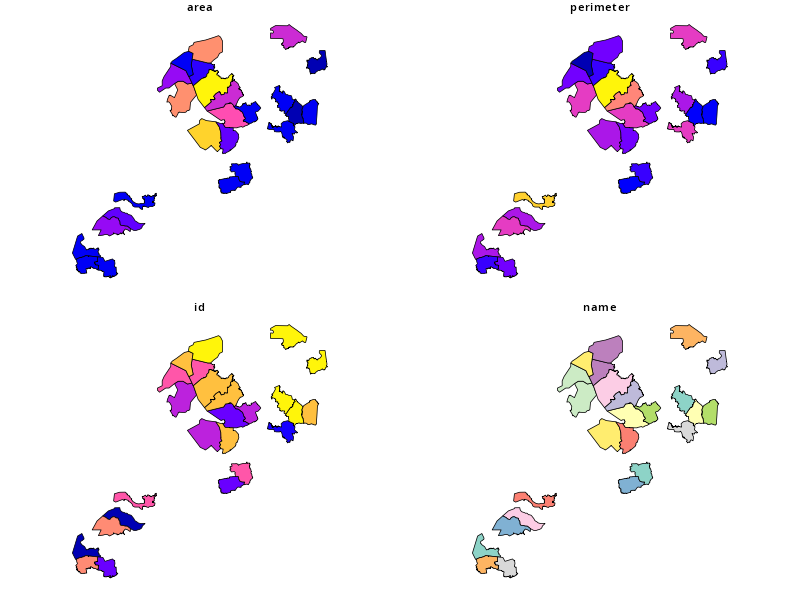

In [110]:
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

### 1.7.2 Return all region boundaries based on postal codes

In [152]:
myurl <- ndc_url(option = "Postalcodes",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/postalcodes?output_epsg=4326&page_size=25&page_offset=0

In [153]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 4 columns

In [113]:
knitr::kable(head(myres_df$features$properties))



|area      |perimeter |id     |postcode |
|:---------|:---------|:------|:--------|
|410441715 |91088.11  |403343 |8244PB   |
|403366190 |108552.2  |454964 |9979XX   |
|319397224 |88601.67  |419369 |8862NZ   |
|250510474 |85933.01  |419737 |8897HE   |
|227928195 |91628.78  |402946 |8242PZ   |
|206176550 |95990.57  |419622 |8881HG   |

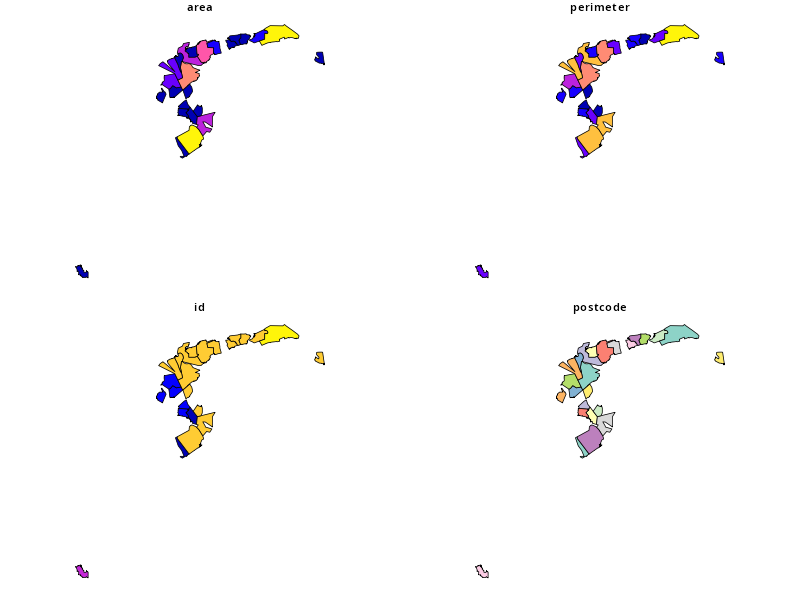

In [114]:
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

### 1.7.3 Return all region boundaries based on provinces

In [154]:
myurl <- ndc_url(option = "Provinces",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/provinces?output_epsg=4326&page_size=25&page_offset=0

In [155]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions: 12 rows x 4 columns

In [117]:
knitr::kable(head(myres_df$features$properties))



|area       |perimeter |id |name          |
|:----------|:---------|:--|:-------------|
|5748751544 |382644.1  |5  |Fryslân       |
|5136514976 |561381.7  |3  |Gelderland    |
|5081754945 |518496.7  |9  |Noord-Brabant |
|4091738584 |394724.8  |10 |Noord-Holland |
|3420863133 |425722    |8  |Overijssel    |
|3418526942 |347276.4  |1  |Zuid-Holland  |

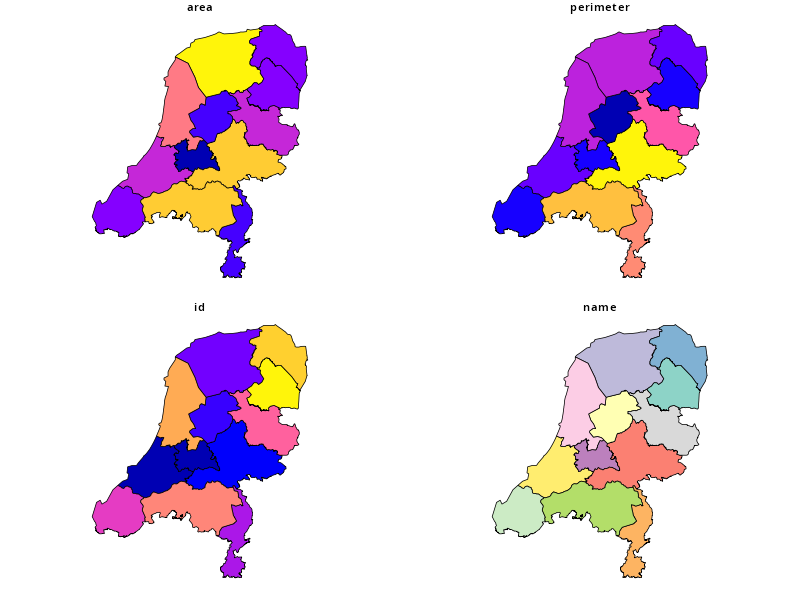

In [118]:
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
plot(myres_sf)

## 1.8 Datapackage

Datapackage has been introduced in summer 2022. A request for a datapackage can return data from different resources for a collection of AgroDataCube fieldids. The format in which data is returned is defined by the datapackage. Currently JSON or GeoJSON are returned.

New requests using datapackages can be added on the fly so it might be possible this documentation is not up to date.

### 1.8.1 KPI - Greenness

In [156]:
myurl <- ndc_url(option = "KPI_Greenness",
                 params = c(fieldids = "9403114"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/datapackage/kpi/greenness?fieldids=9403114

In [157]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))

In [158]:
myres_field <- fromJSON(myres_sf$field, simplifyDataFrame = TRUE)
cat("Length:", length(myres_df$features$properties), "values")

Length: 4 values

In [164]:
knitr::kable(data.frame(value = unlist(myres_field)))



|          |value              |
|:---------|:------------------|
|fieldid   |9403114            |
|crop_code |265                |
|area      |40938.2088         |
|year      |2020               |
|crop_name |Grasland, blijvend |

In [171]:
myres_ndvi <- fromJSON(myres_sf$ndvi, simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_ndvi), "rows x", ncol(myres_ndvi), "columns")

Dimensions: 39 rows x 4 columns

In [172]:
knitr::kable(head(myres_ndvi, 10))



|datum      | ndvi_avg| ndvi_stddev| daynr|
|:----------|--------:|-----------:|-----:|
|2020-02-05 |   0.7579|      0.0305|    36|
|2020-03-23 |   0.7507|      0.0362|    83|
|2020-03-26 |   0.7292|      0.0380|    86|
|2020-03-31 |   0.7596|      0.0357|    91|
|2020-04-05 |   0.7818|      0.0308|    96|
|2020-04-07 |   0.7839|      0.0207|    98|
|2020-04-15 |   0.9147|      0.0175|   106|
|2020-04-17 |   0.9111|      0.0214|   108|
|2020-04-19 |   0.8858|      0.0562|   110|
|2020-04-20 |   0.9275|      0.0222|   111|

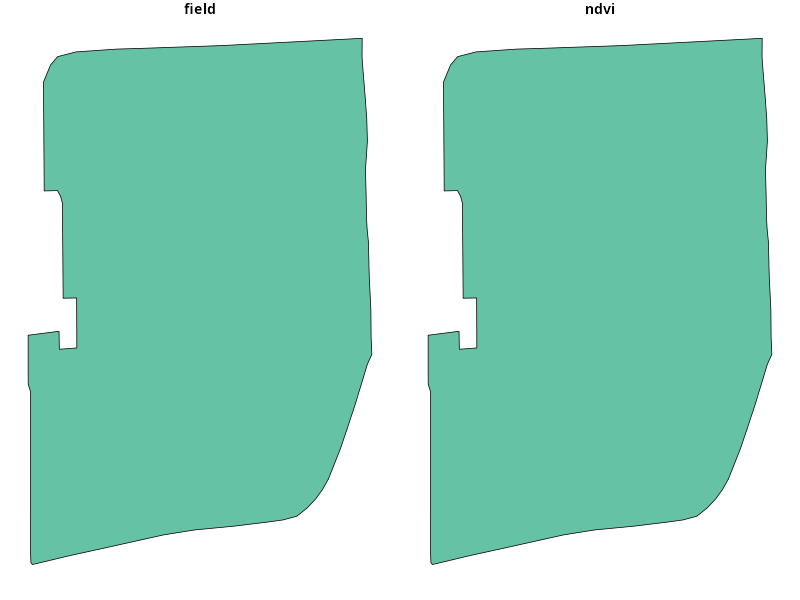

In [173]:
suppressWarnings(plot(myres_sf))

### 1.8.2 KPI - Croprotation

In [174]:
myurl <- ndc_url(option = "KPI_Croprotation",
                 params = c(fieldids = "9403114"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/datapackage/kpi/croprotation?fieldids=9403114

In [175]:
myres <- ndc_get(url = myurl, token = mytoken)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))

In [177]:
myres_field <- fromJSON(myres_sf$field, simplifyDataFrame = TRUE)
cat("Length:", length(myres_field), "values")

Length: 3 values

In [181]:
knitr::kable(data.frame(value = unlist(myres_field)))



|          |value      |
|:---------|:----------|
|fieldid   |9403114    |
|crop_code |265        |
|area      |40938.2088 |

In [183]:
myres_crophistory <- fromJSON(myres_sf$crop_history, simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_crophistory), "rows x", ncol(myres_crophistory), "columns")

Dimensions: 12 rows x 5 columns

In [184]:
knitr::kable(head(myres_crophistory, 10))



|crop_code_in_year | year| fieldid_in_year| intersected_area|     area|
|:-----------------|----:|---------------:|----------------:|--------:|
|265               | 2020|         9403114|         40938.21| 40938.21|
|265               | 2019|         9289293|         40902.06| 41279.96|
|265               | 2018|         8584057|         40938.21| 41316.10|
|265               | 2010|         1441244|         40676.97| 42313.72|
|265               | 2011|         2373534|         40677.01| 42317.87|
|265               | 2012|         2502970|         40855.59| 42359.02|
|265               | 2013|         3651395|         40855.59| 42359.02|
|265               | 2014|         4663439|         40855.59| 42359.02|
|265               | 2015|         5142822|         40855.59| 42359.02|
|265               | 2016|         6180491|         40317.46| 40695.40|

In [187]:
myres_cropinformation <- fromJSON(myres_sf$cropinformation, simplifyDataFrame = TRUE)
cat("Length:", length(myres_cropinformation), "values")

Length: 7 values

In [197]:
knitr::kable(data.frame(value = unlist(myres_cropinformation)))



|                 |value              |
|:----------------|:------------------|
|cropcode         |265                |
|cropname         |Grasland, blijvend |
|grondgebruik     |Grasland           |
|cropid           |209                |
|conflict         |FALSE              |
|standard_revenue |1250               |

In [199]:
myres_croprotationindex <- fromJSON(myres_sf$croprotationindex, simplifyDataFrame = TRUE)
cat("Length:", length(myres_croprotationindex), "values")

Length: 3 values

In [203]:
knitr::kable(data.frame(value = unlist(myres_croprotationindex)))



|         |   value|
|:--------|-------:|
|fieldid  | 9403114|
|index    |       1|
|numyears |       6|

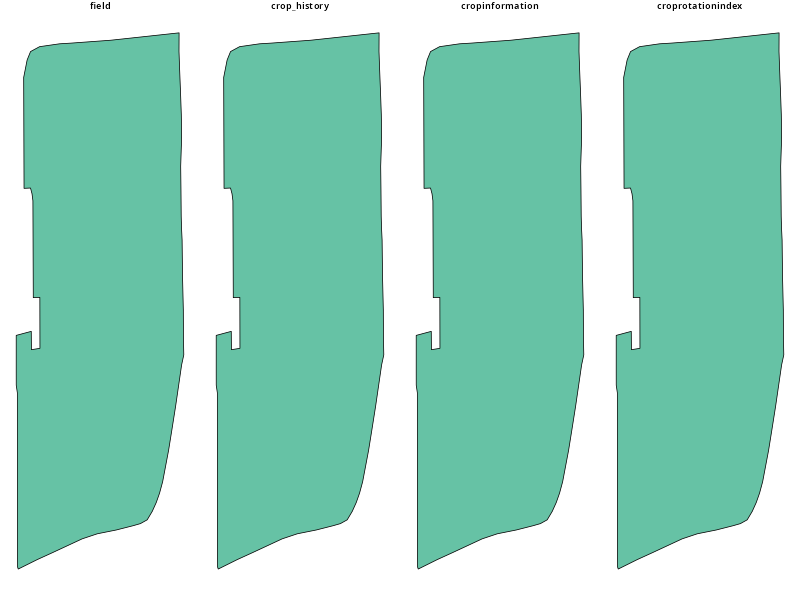

In [204]:
suppressWarnings(plot(myres_sf))

# 2. Using the *GroenMonitor* WCS interface

## 2.1 RGB

In [206]:
myurl <- gm_url(option = "RGB", params = myparams)
cat(myurl)

https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__rgb_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff

In [207]:
myfile <- paste(tempdir(), "./rgb_20251225.tif", sep = "/")
gm_get(url = myurl, out_path = myfile)

Response [https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__rgb_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff]
  Date: 2026-02-19 17:57
  Status: 200
  Content-Type: image/tiff
  Size: 74.1 kB
<ON DISK>  /tmp/RtmphORECn/./rgb_20251225.tif

In [208]:
mydata <- rast(myfile)
print(mydata)

class       : SpatRaster 
dimensions  : 91, 129, 3  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 684610, 685900, 5763910, 5764820  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : rgb_20251225.tif 
colors RGB  : 1, 2, 3 
names       : rgb_20251225_1, rgb_20251225_2, rgb_20251225_3 


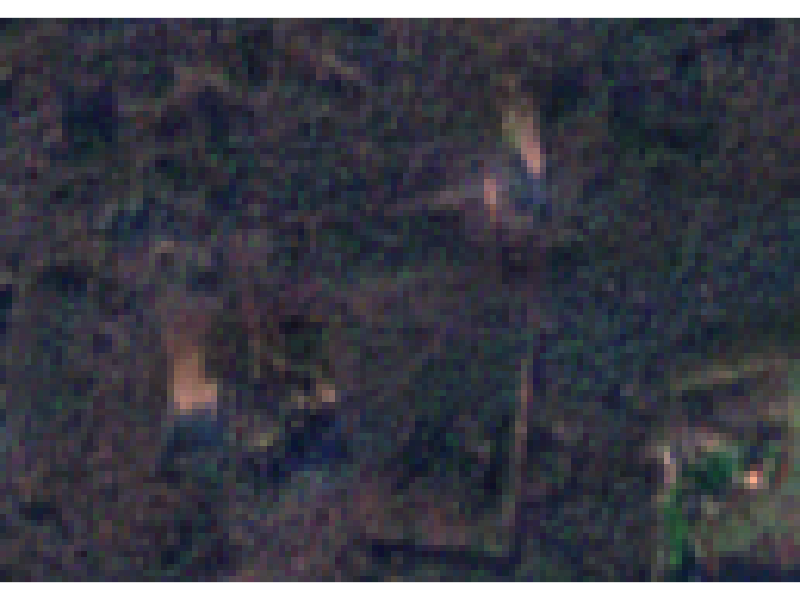

In [209]:
plot(mydata)

## 2.2 NDVI

In [210]:
myurl <- gm_url(option = "NDVI", params = myparams)
cat(myurl)

https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__ndvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff

In [211]:
myfile <- paste(tempdir(), "./ndvi_20251225.tif", sep = "/")
gm_get(url = myurl, out_path = myfile)

Response [https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__ndvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff]
  Date: 2026-02-19 17:57
  Status: 200
  Content-Type: image/tiff
  Size: 25 kB
<ON DISK>  /tmp/RtmphORECn/./ndvi_20251225.tif

In [212]:
mydata <- rast(myfile)
print(mydata)

class       : SpatRaster 
dimensions  : 91, 129, 1  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 684610, 685900, 5763910, 5764820  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : ndvi_20251225.tif 
name        : ndvi_20251225 


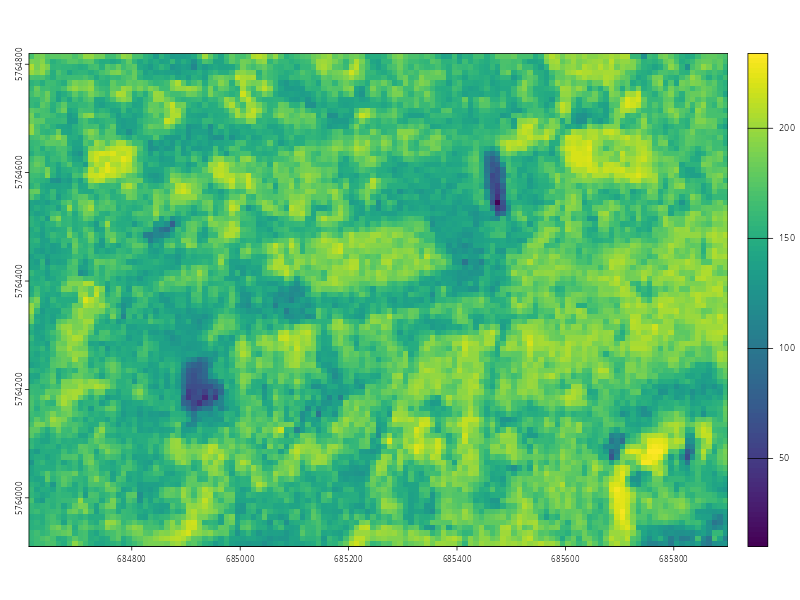

In [213]:
plot(mydata)

## 2.3 WDVI

In [214]:
myurl <- gm_url(option = "WDVI", params = myparams)
cat(myurl)

https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__wdvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff

In [215]:
myfile <- paste(tempdir(), "./wdvi_20251225.tif", sep = "/")
gm_get(url = myurl, out_path = myfile)

Response [https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__wdvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff]
  Date: 2026-02-19 17:57
  Status: 200
  Content-Type: image/tiff
  Size: 25 kB
<ON DISK>  /tmp/RtmphORECn/./wdvi_20251225.tif

In [216]:
mydata <- rast(myfile)
print(mydata)

class       : SpatRaster 
dimensions  : 91, 129, 1  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 684610, 685900, 5763910, 5764820  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : wdvi_20251225.tif 
name        : wdvi_20251225 


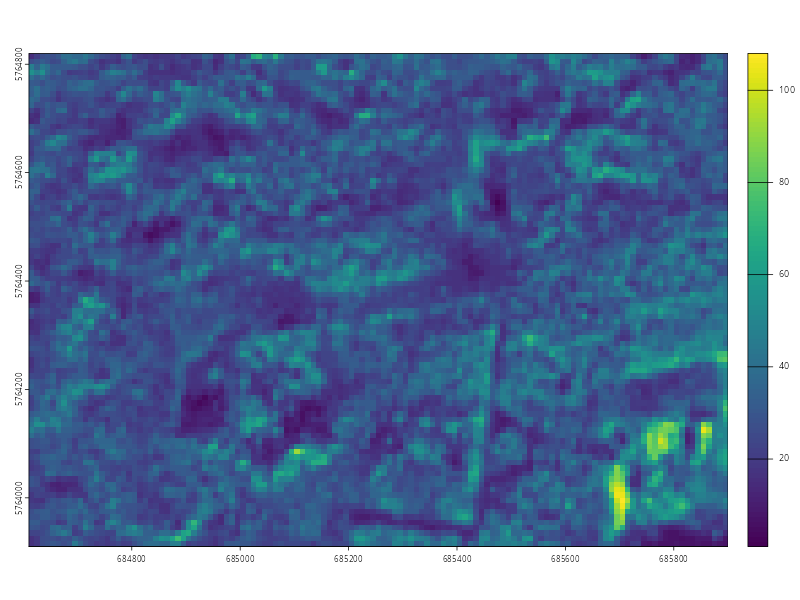

In [217]:
plot(mydata)

# 3. Using the *AgroDataCube* test server

## 3.1. Health check

In [227]:
myurl <- ndc_url(option = "Health_check")
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/lifeprobe

In [235]:
myres <- ndc_get(url = myurl, token = mytoken)
if (!is.null(myres)) {
  cat("✓ API is alive!\n")
} else {
  cat("Something went wrong...\n")
}

✓ API is alive!


## 3.2. Get Field (ID: 51264469)

In [ ]:
myurl <- ndc_url(option = "Fields",
                 params = c(fieldid     = "51264469",
                            output_epsg = "28992"),
                 base_url = "https://agrodatacube-test.containers.wur.nl/api/v2/rest/")
cat(myurl)

https://agrodatacube-test.containers.wur.nl/api/v2/rest/fields?fieldid=51264469&output_epsg=28992

In [6]:
myres <- ndc_get(url = myurl, token = mytoken2)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
knitr::kable(myres_df$metadata)



|column_name  |description                                                                            |units |
|:------------|:--------------------------------------------------------------------------------------|:-----|
|area         |Area of a geometry                                                                     |m2    |
|crop_code    |Code for the crop as supplied by RVO                                                   |NULL  |
|crop_name    |Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years. |NULL  |
|fieldid      |Unique id of a parcel in the AgroDataCube unique per parcel per year                   |NULL  |
|geom         |The geometry of an object or intersection depending on the resource and the parameters |NULL  |
|grondgebruik |Categorized landuse at the parcel                                                      |NULL  |
|perimeter    |Perimeter of geometry                                                                  |m     |

## 3.3. Get Field (ID: 51264470)

In [7]:
myurl <- ndc_url(option = "Fields",
                 params = c(fieldid     = "51264470",
                            output_epsg = "28992"),
                 base_url = "https://agrodatacube-test.containers.wur.nl/api/v2/rest/")
cat(myurl)

https://agrodatacube-test.containers.wur.nl/api/v2/rest/fields?fieldid=51264470&output_epsg=28992

In [8]:
myres <- ndc_get(url = myurl, token = mytoken2)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
knitr::kable(myres_df$metadata)



|column_name  |description                                                                            |units |
|:------------|:--------------------------------------------------------------------------------------|:-----|
|area         |Area of a geometry                                                                     |m2    |
|crop_code    |Code for the crop as supplied by RVO                                                   |NULL  |
|crop_name    |Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years. |NULL  |
|fieldid      |Unique id of a parcel in the AgroDataCube unique per parcel per year                   |NULL  |
|geom         |The geometry of an object or intersection depending on the resource and the parameters |NULL  |
|grondgebruik |Categorized landuse at the parcel                                                      |NULL  |
|perimeter    |Perimeter of geometry                                                                  |m     |

## 3.4. Get NDVI (ID: 51264469)

In [18]:
myurl <- ndc_url(option = "NDVI",
                 params = c(fieldid = "51264469"),
                 base_url = "https://agrodatacube-test.containers.wur.nl/api/v2/rest/")
cat(myurl)

https://agrodatacube-test.containers.wur.nl/api/v2/rest/ndvi?fieldid=51264469

In [19]:
myres <- ndc_get(url = myurl, token = mytoken2)
myres_df <- fromJSON(toJSON(myres), simplifyDataFrame = TRUE)
cat("Dimensions:", nrow(myres_df$features$properties), "rows x", ncol(myres_df$features$properties), "columns")

Dimensions: 44 rows x 5 columns

## 3.5. Polygon Query (Geometry Search)

In [21]:
myurl <- ndc_url(option = "Fields",
                 params = c(geometry    = mypolygon3,
                            output_epsg = "28992",
                            year        = 2025),
                 base_url = "https://agrodatacube-test.containers.wur.nl/api/v2/rest/")
cat(myurl)

https://agrodatacube-test.containers.wur.nl/api/v2/rest/fields?geometry=POLYGON((175742%20445233,175742%20446118,177050%20446118,177050%20445233,175742%20445233))&output_epsg=28992&year=2025

In [22]:
myres <- ndc_get(url = myurl, token = mytoken2)
myres_sf <- geojson_sf(toJSON(myres, auto_unbox = TRUE))
print(myres_sf)

Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 175742.8 ymin: 445233.4 xmax: 177049.7 ymax: 446118
Geodetic CRS:  WGS 84
    area  grondgebruik crop_code year   crop_name perimeter  fieldid
1 618453 Natuurterrein      9999 2025 LTER Natuur  3512.622 51264469
                        geometry
1 POLYGON ((175787.2 445865.4...


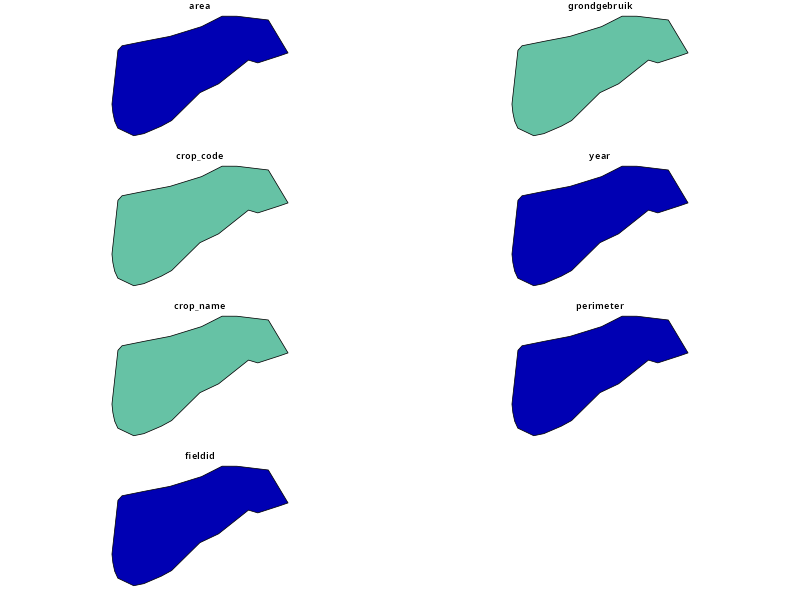

In [24]:
suppressWarnings(plot(myres_sf))

## 3.6. Nested Path (fields/51264469/ndvi)

In [ ]:
myurl <- ndc_url(option = "NDVI",
                 params = c(output_epsg = "4326",
                            fromdate    = "20250101",
                            todate      = "20260101",
                            page_size   = "366",
                            page_offset = "0"),
                 base_url = "https://agrodatacube-test.containers.wur.nl/api/v2/rest/")
cat(myurl)

myurl == "https://agrodatacube-test.containers.wur.nl/api/v2/rest/fields/51264469/ndvi?output_epsg=4326&fromdate=20250101&todate=20260101&page_size=366&page_offset=0"

# TODO: fix nested paths

https://agrodatacube-test.containers.wur.nl/api/v2/rest/ndvi?output_epsg=4326&fromdate=20250101&todate=20260101&page_size=366&page_offset=0

[1] FALSE